In [44]:
from rdkit import Chem
from rdkit.Chem.Draw import SimilarityMaps

import io
from PIL import Image
from pathlib import Path
import torch
import random
from bcosgnn.data.mutag import mol_from_mutag_data

In [45]:
def show_png(data):
    bio = io.BytesIO(data)
    img = Image.open(bio)
    return img


def molecule_atom_attributions_to_image(
    mol: Chem.Mol = None,
    atom_weights: list[float] = None,
    smiles: str = None,
    img_size: int = 400,
    **kwargs,
):
    mol = mol or Chem.MolFromSmiles(smiles)
    num_atoms = mol.GetNumAtoms()
    assert len(atom_weights) == num_atoms, (
        f"Expected num atoms {num_atoms} to match num weights {len(atom_weights)}"
    )
    d = Chem.Draw.MolDraw2DCairo(img_size, img_size)
    d = SimilarityMaps.GetSimilarityMapFromWeights(mol, atom_weights, d, **kwargs)
    # d.DrawString("blub", Point2D(5, 1))
    print((dir(d)))
    return show_png(d.GetDrawingText())

In [46]:
run_dir = Path("../lightning_logs/version_12")
expl_file = run_dir / "explanations.pt"
assert expl_file.exists()
explanations = torch.load(expl_file, weights_only=False)
explanations_items = list(explanations.items())

In [47]:
import time


random.seed(time.time())
random.shuffle(explanations_items)
for key, value in explanations_items:
    logit = value["predicted_logit"]
    pred = torch.sigmoid(logit).item()
    break

In [48]:
value["data"].y, logit, pred

(tensor([0]), tensor([-0.6547], requires_grad=True), 0.34194034337997437)

20 20


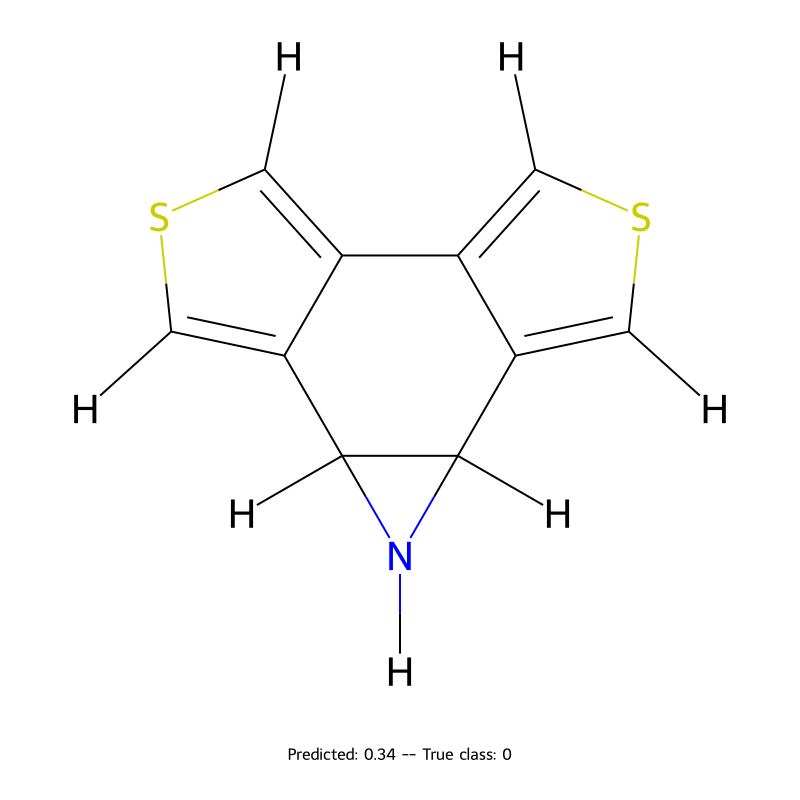

In [49]:
# mol = Chem.MolFromSmiles(key)
mol = mol_from_mutag_data(value["data"])
print(mol.GetNumAtoms(), value["data"].num_nodes)
Chem.Draw.MolToImage(
    mol,
    size=(800, 800),
    legend=f"Predicted: {pred:.2f} -- True class: {value['data'].y.item()}",
)

In [50]:
atom_contribution_map = value["x"]["contribution_map"].sum(1).tolist()
bond_contribution_map = value["edge_attr"]["contribution_map"].sum(1).tolist()

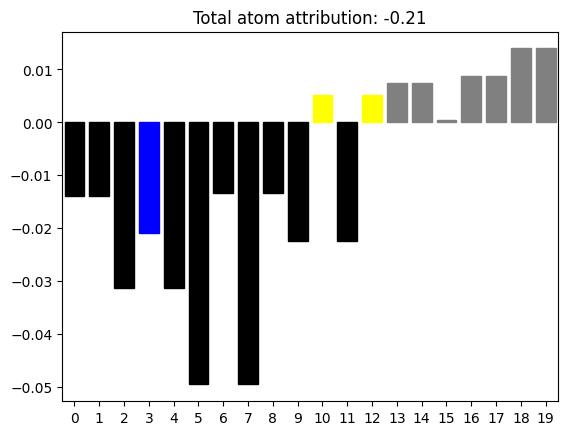

In [51]:
import seaborn as sns

total_attribution = sum(atom_contribution_map)
bar_colors = []
for atom in mol.GetAtoms():
    symb = atom.GetSymbol()
    if symb == "C":
        bar_colors.append("black")
    elif symb == "O":
        bar_colors.append("red")
    elif symb == "N":
        bar_colors.append("blue")
    elif symb == "Cl":
        bar_colors.append("green")
    elif symb == "F":
        bar_colors.append("turquoise")
    elif symb == "S":
        bar_colors.append("yellow")
    else:
        bar_colors.append("grey")
ax = sns.barplot(x=range(len(atom_contribution_map)), y=atom_contribution_map)
ax.set_title(f"Total atom attribution: {total_attribution:.2f}")
# set bar colors
for i, bar in enumerate(ax.patches):
    bar.set_color(bar_colors[i])

['ClearDrawing', 'DrawArc', 'DrawArrow', 'DrawAttachmentLine', 'DrawEllipse', 'DrawLine', 'DrawMolecule', 'DrawMoleculeWithHighlights', 'DrawMolecules', 'DrawPolygon', 'DrawReaction', 'DrawRect', 'DrawString', 'DrawTriangle', 'DrawWavyLine', 'FillPolys', 'FinishDrawing', 'FlexiMode', 'FontSize', 'GetDrawCoords', 'GetDrawingText', 'GetMolSize', 'Height', 'LineWidth', 'Offset', 'SetColour', 'SetDrawOptions', 'SetFillPolys', 'SetFlexiMode', 'SetFontSize', 'SetLineWidth', 'SetOffset', 'SetScale', 'Width', 'WriteDrawingText', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__instance_size__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'drawOptions']


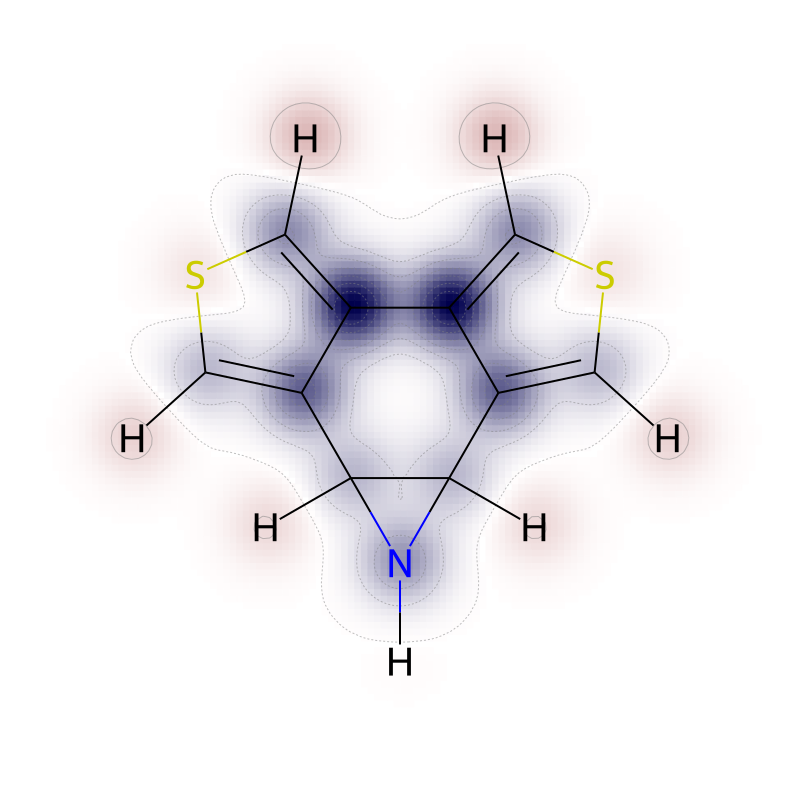

In [52]:
molecule_atom_attributions_to_image(
    mol=mol,
    atom_weights=atom_contribution_map,
    img_size=800,
    colorMap="seismic",
)

Text(0.5, 1.0, 'Total bond attribution: -0.44')

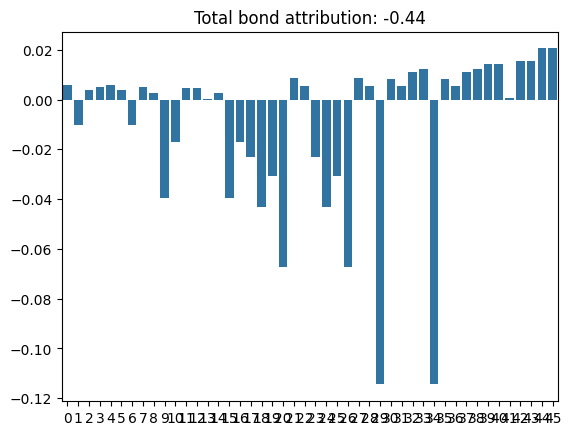

In [53]:
import seaborn as sns

total_attribution = sum(bond_contribution_map)
ax = sns.barplot(x=range(len(bond_contribution_map)), y=bond_contribution_map)
ax.set_title(f"Total bond attribution: {total_attribution:.2f}")

In [54]:
def bond_to_atom_contributions(contrib_bonds, num_atoms, edge_index):
    contrib_atoms = torch.zeros(num_atoms)
    for i, (a, b) in enumerate(edge_index.T):
        contrib_atoms[a] += contrib_bonds[i]
        contrib_atoms[b] += contrib_bonds[i]
    return contrib_atoms.tolist()

['ClearDrawing', 'DrawArc', 'DrawArrow', 'DrawAttachmentLine', 'DrawEllipse', 'DrawLine', 'DrawMolecule', 'DrawMoleculeWithHighlights', 'DrawMolecules', 'DrawPolygon', 'DrawReaction', 'DrawRect', 'DrawString', 'DrawTriangle', 'DrawWavyLine', 'FillPolys', 'FinishDrawing', 'FlexiMode', 'FontSize', 'GetDrawCoords', 'GetDrawingText', 'GetMolSize', 'Height', 'LineWidth', 'Offset', 'SetColour', 'SetDrawOptions', 'SetFillPolys', 'SetFlexiMode', 'SetFontSize', 'SetLineWidth', 'SetOffset', 'SetScale', 'Width', 'WriteDrawingText', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__instance_size__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'drawOptions']


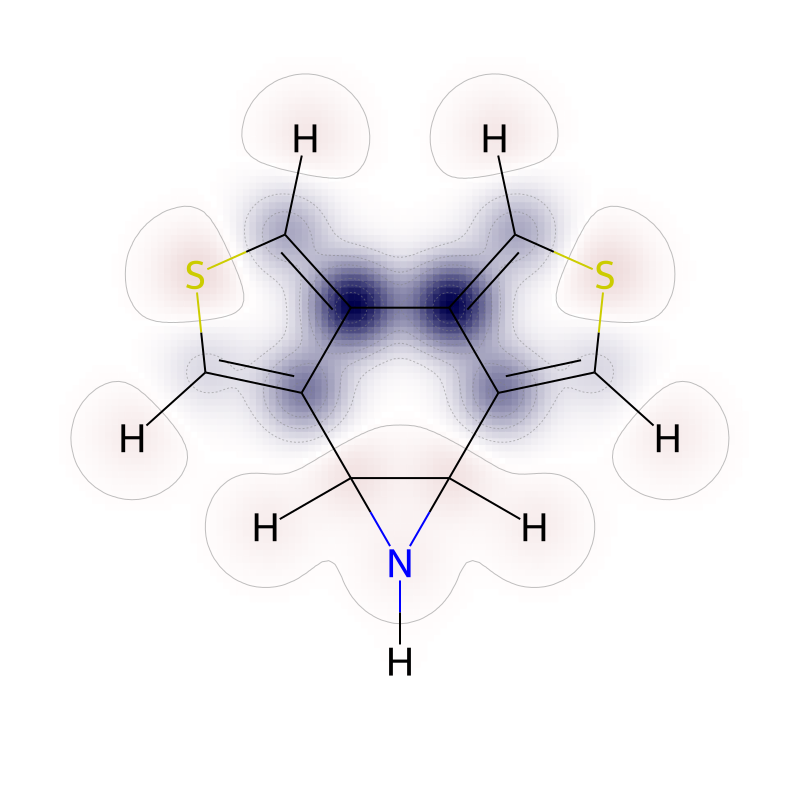

In [55]:
molecule_atom_attributions_to_image(
    mol=mol,
    atom_weights=bond_to_atom_contributions(
        bond_contribution_map, len(atom_contribution_map), value["data"]["edge_index"]
    ),
    img_size=800,
    colorMap="seismic",
)

In [56]:
import copy


def fuse_contributions(contrib_atoms, contrib_bonds, edge_index):
    fused = copy.deepcopy(contrib_atoms)
    for (i, j), contrib in zip(edge_index, contrib_bonds):
        fused[i] += contrib / 2
        fused[j] += contrib / 2
    return fused

In [57]:
fused_contributions = fuse_contributions(
    atom_contribution_map, bond_contribution_map, value["data"].edge_index.T.tolist()
)

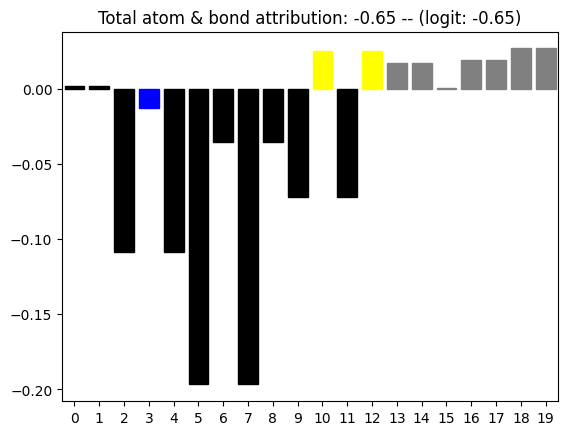

In [58]:
import seaborn as sns

total_attribution = sum(fused_contributions)
ax = sns.barplot(x=range(len(fused_contributions)), y=fused_contributions)
ax.set_title(
    f"Total atom & bond attribution: {total_attribution:.2f} -- (logit: {float(logit):.2f})"
)
for i, bar in enumerate(ax.patches):
    bar.set_color(bar_colors[i])

['ClearDrawing', 'DrawArc', 'DrawArrow', 'DrawAttachmentLine', 'DrawEllipse', 'DrawLine', 'DrawMolecule', 'DrawMoleculeWithHighlights', 'DrawMolecules', 'DrawPolygon', 'DrawReaction', 'DrawRect', 'DrawString', 'DrawTriangle', 'DrawWavyLine', 'FillPolys', 'FinishDrawing', 'FlexiMode', 'FontSize', 'GetDrawCoords', 'GetDrawingText', 'GetMolSize', 'Height', 'LineWidth', 'Offset', 'SetColour', 'SetDrawOptions', 'SetFillPolys', 'SetFlexiMode', 'SetFontSize', 'SetLineWidth', 'SetOffset', 'SetScale', 'Width', 'WriteDrawingText', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__instance_size__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'drawOptions']


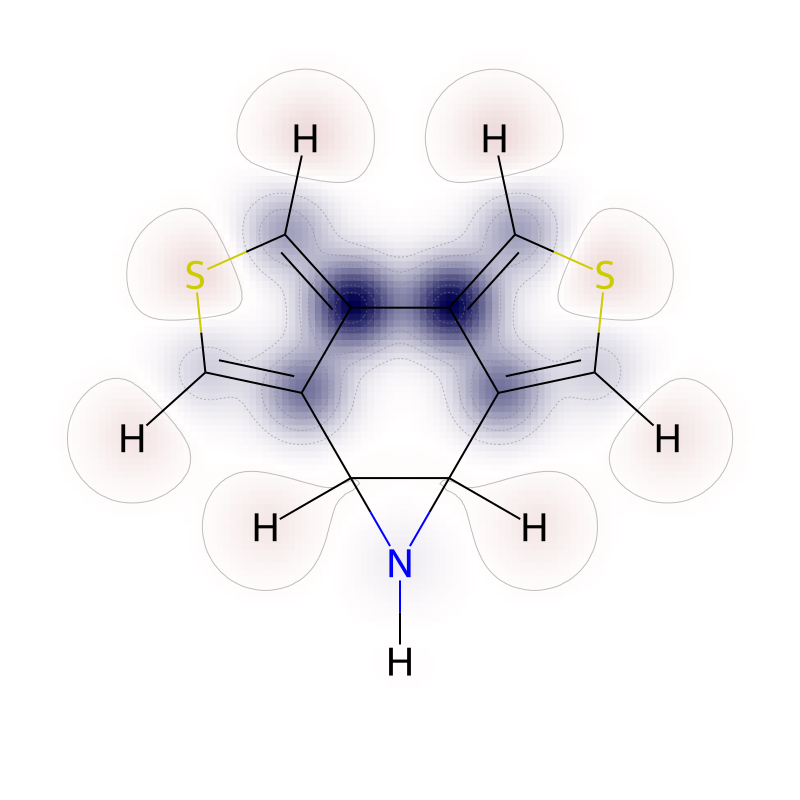

In [59]:
molecule_atom_attributions_to_image(
    mol=mol, atom_weights=fused_contributions, img_size=800, colorMap="seismic"
)